In [15]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from qiskit import * 
from qiskit_aer import AerSimulator
import math
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_histogram
from IPython.display import display
%matplotlib inline

In [16]:
### --- CONFIG --- ###

## ABSTRACTION ##

# abstraction level (1 -> low, 2 -> medium, 3 -> high, 4 -> max, else -> raw)
abstraction_level = 0

## ----------- ##


## GROVER ##

# target iterations (-1 to use target probability)
k_target = -1

# target probability (1.0 for optimal iterations)
p_target = 1.0

## ------ ##

### --- ------ --- ###

In [17]:
# PARAMS

# board dim
N = 4

# state dim
n = 8

# solutions count
M = 2

# grover iterations
grover_iterations = None
if (k_target == -1):
    grover_iterations = round(math.asin(math.sqrt(p_target)) / (2 * math.asin(math.sqrt(M/(2**n)))) - 0.5)
else:
    grover_iterations = k_target

In [18]:
# EXECUTION (Aer QASM simulation)
def execution(qc, shots=1024):
    backend = AerSimulator()
    backend.set_options(seed_simulator=42)

    qc_compiled = transpile(RemoveBarriers()(qc),optimization_level=3,seed_transpiler=42,
                            basis_gates=['u1', 'u2', 'u3', 'x', 'cx', 'h', 's', 'sdg', 't', 'tdg'])
    
    job = backend.run(qc_compiled, shots=shots)
    result = job.result()
    counts = result.get_counts()

    print("Depth:", qc_compiled.depth())
    print("Gates:", qc_compiled.count_ops())
    
    return counts

In [19]:
# DIFFUSER
def diffuser(dif_qc):
    dif_qc.h(range(n))
    dif_qc.x(range(n))

    dif_qc.barrier(range(n))

    dif_qc.h(n-1)
    dif_qc.mcx(list(range(n-1)), n-1)
    dif_qc.h(n-1)

    dif_qc.barrier(range(n))

    dif_qc.x(range(n))
    dif_qc.h(range(n))

    return dif_qc

In [20]:
# BITWISE qXOR OPERATOR 
def bitwise_qxor(qc):
    qc.cx(0,2)
    qc.cx(1,3)    
    
    return qc

In [21]:
# COL CHECK OPERATOR
def col_check(qc):
    qc.ccx(0,1,2) # collision if equal
    
    return qc

In [22]:
# COL EQ OPERATOR
def col_eq(qc, raw):
    
    # bitwise qXOR operator
    bw_qxor_qc = bitwise_qxor(QuantumCircuit(4))

    # bitwise qXOR inverse operator
    bw_qxor_qc_inv = bw_qxor_qc.inverse()

    # column check operator
    col_check_qc = col_check(QuantumCircuit(3))


    # raw case
    if raw:

        ## QO ---

        # Q0 fanout compute
        qc.compose(bw_qxor_qc,[0,1,8,9],inplace=True)     

        qc.barrier()       

        # Q0 --- Q1
        qc.compose(bw_qxor_qc,[2,3,8,9],inplace=True)               # Q0 qXOR Q1 compute
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,11],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[2,3,8,9],inplace=True)           # Q0 qXOR Q1 uncompute

        qc.barrier()
        
        # Q0 --- Q2
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True)               # Q0 qXOR Q2 compute
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,12],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)           # Q0 qXOR Q2 uncompute

        qc.barrier()
        
        # Q0 --- Q3
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)               # Q0 qXOR Q3 compute
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,13],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)           # Q0 qXOR Q3 uncompute

        qc.barrier()

        # Q0 fanout uncompute
        qc.compose(bw_qxor_qc_inv,[0,1,8,9],inplace=True)

        ##

        qc.barrier()

        ## Q1 ---

        # Q1 fanout compute
        qc.compose(bw_qxor_qc,[2,3,8,9],inplace=True) 

        qc.barrier()

        # Q1 --- Q2
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True)               # Q1 qXOR Q2 compute        
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,14],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)           # Q1 qXOR Q2 uncompute  

        qc.barrier()

        # Q1 --- Q3
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)               # Q1 qXOR Q3 compute     
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,15],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)           # Q1 qXOR Q3 uncompute 

        qc.barrier()

        # Q1 fanout uncompute
        qc.compose(bw_qxor_qc_inv,[2,3,8,9],inplace=True)

        ##

        qc.barrier()

        ## Q2 ---

        # Q2 fanout compute
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True) 

        qc.barrier()

        # Q2 --- Q3
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)               # Q2 qXOR Q3 compute     
        qc.barrier(range(8,17))
        qc.compose(col_check_qc,[8,9,16],inplace=True)              # qAND([xor₀, xor₁]) 
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)           # Q2 qXOR Q3 uncompute 

        qc.barrier()

        # Q2 fanout uncompute
        qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)

        ##


    # abstraction case
    else:

        ## QO ---

        # Q0 fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q0 FANOUT    \n\nCompute'),[0,1,8,9],inplace=True)           

        # Q0 --- Q1
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label='      Q0      \nqXOR\nQ1\n\nCompute'),[0,1,2,3],inplace=True)                # Q0 qXOR Q1 compute
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label='      Q0      \nqXOR\nQ1\n\nUncompute'),[0,1,2,3],inplace=True)          # Q0 qXOR Q1 uncompute
        qc.compose(ceq_pair_qc.to_gate(label='      Q0      \nqEQ\nQ1'), [2,3,8,9,11], inplace=True)                                # Q0 qEQ Q1                   
        
        # Q0 --- Q2
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      Q0      \nqXOR\nQ2\n\nCompute'),[0,1,2,3],inplace=True)                # Q0 qXOR Q2 compute
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      Q0      \nqXOR\nQ2\n\nUncompute'),[0,1,2,3],inplace=True)          # Q0 qXOR Q2 uncompute
        qc.compose(ceq_pair_qc.to_gate(label='      Q0      \nqEQ\nQ2'), [4,5,8,9,12], inplace=True)                                # Q0 qEQ Q2 
        
        # Q0 --- Q3
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      Q0      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)                # Q0 qXOR Q3 compute
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      Q0      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)          # Q0 qXOR Q3 uncompute
        qc.compose(ceq_pair_qc.to_gate(label='      Q0      \nqEQ\nQ3'), [6,7,8,9,13], inplace=True)                                # Q0 qEQ Q3


        # Q0 fanout uncompute
        qc.compose(bw_qxor_qc_inv.to_gate(label='    Q0 FANOUT    \n\nUncompute'),[0,1,8,9],inplace=True)

        ##


        ## Q1 ---

        # Q1 fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q1 FANOUT    \n\nCompute'),[2,3,8,9],inplace=True)   


        # Q1 --- Q2
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      Q1      \nqXOR\nQ2\n\nCompute'),[0,1,2,3],inplace=True)                # Q1 qXOR Q2 compute        
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      Q1      \nqXOR\nQ2\n\nUncompute'),[0,1,2,3],inplace=True)          # Q1 qXOR Q2 uncompute  
        qc.compose(ceq_pair_qc.to_gate(label='      Q1      \nqEQ\nQ2'), [4,5,8,9,14], inplace=True)                                # Q1 qEQ Q2 

        # Q1 --- Q3
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      Q1      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)                # Q1 qXOR Q3 compute     
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      Q1      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)          # Q1 qXOR Q3 uncompute
        qc.compose(ceq_pair_qc.to_gate(label='      Q1      \nqEQ\nQ3'), [6,7,8,9,15], inplace=True)                                # Q1 qEQ Q3 


        # Q1 fanout uncompute
        qc.compose(bw_qxor_qc_inv.to_gate(label='    Q1 FANOUT    \n\nUncompute'),[2,3,8,9],inplace=True)

        ##


        ## Q2 ---

        # Q2 fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q2 FANOUT    \n\nCompute'),[4,5,8,9],inplace=True)   


        # Q2 --- Q3
        ceq_pair_qc = QuantumCircuit(5, name='ceq_pair')
        ceq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      Q2      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)                # Q2 qXOR Q3 compute     
        ceq_pair_qc.compose(col_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081])    '),[2,3,4],inplace=True)              # qAND([xor₀, xor₁]) 
        ceq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      Q2      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)          # Q2 qXOR Q3 uncompute 
        qc.compose(ceq_pair_qc.to_gate(label='      Q2      \nqEQ\nQ3'), [6,7,8,9,16], inplace=True)                                # Q2 qEQ Q3 


        # Q2 fanout uncompute
        qc.compose(bw_qxor_qc_inv.to_gate(label='    Q2 FANOUT    \n\nUncompute'),[4,5,8,9],inplace=True)

        ##

    return qc

In [23]:
# DIAG CHECK OPERATOR
def diag_check(qc):
    qc.mcx(list(range(3)),3) # collision if equal and no overflow
    
    return qc

In [24]:
# INCREMENTER OPERATOR
def incrementer(qc):
    qc.ccx(0,1,2) # overflow check
    qc.cx(0,1)
    qc.x(0)

    return qc

In [25]:
# DIAG EQ OPERATOR
def diag_eq(qc, ctr_qc, raw):

    # counter inverse operator
    ctr_qc_inv = ctr_qc.inverse()

    # bitwise qXOR operator
    bw_qxor_qc = bitwise_qxor(QuantumCircuit(4))

    # bitwise qXOR inverse operator
    bw_qxor_qc_inv = bw_qxor_qc.inverse()

    # diag check operator
    diag_check_qc = diag_check(QuantumCircuit(4))


    # raw case
    if raw:

        ## Q0 ---

        # QO fanout compute
        qc.compose(bw_qxor_qc,[0,1,8,9],inplace=True)

        qc.barrier()

        # Q0 +/- 1 compute 
        qc.compose(ctr_qc,[8,9,10],inplace=True)                      
        
        # Q0 +/- 1 --- Q1
        qc.barrier()
        qc.compose(bw_qxor_qc,[2,3,8,9],inplace=True)                   # (Q0 +/- 1) qXOR Q1 compute            
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,11],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[2,3,8,9],inplace=True)               # (Q0 +/- 1) qXOR Q1 uncompute 
        qc.barrier()

        # Q0 +/- 2 compute
        qc.compose(ctr_qc,[8,9,10],inplace=True)

        # Q0 +/- 2 --- Q2
        qc.barrier()
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True)                   # (Q0 +/- 2) qXOR Q2 compute 
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,12],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)               # (Q0 +/- 2) qXOR Q2 uncompute 
        qc.barrier()

        # Q0 +/- 3 compute
        qc.compose(ctr_qc,[8,9,10],inplace=True)                       

        # Q0 +/- 3 --- Q3
        qc.barrier()
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)                   # (Q0 +/- 3) qXOR Q3 compute 
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,13],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)               # (Q0 +/- 3) qXOR Q3 uncompute 
        qc.barrier()
        
        # Q0 +/- 3 uncompute
        qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

        qc.barrier()

        # Q0 +/- 2 uncompute
        qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

        qc.barrier()
        
        # Q0 +/- 1 uncompute
        qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

        qc.barrier()

        # QO fanout uncompute
        qc.compose(bw_qxor_qc_inv,[0,1,8,9],inplace=True)

        ##

        qc.barrier()

        ## Q1 ---

        # Q1 fanout compute
        qc.compose(bw_qxor_qc,[2,3,8,9],inplace=True)

        qc.barrier()
        
        # Q1 +/- 1 compute
        qc.compose(ctr_qc,[8,9,10],inplace=True)

        # Q1 +/- 1 --- Q2
        qc.barrier()
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True)                   # (Q1 +/- 1) qXOR Q2 compute 
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,14],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)               # (Q1 +/- 1) qXOR Q2 uncompute
        qc.barrier()

        # Q1 +/- 2 compute
        qc.compose(ctr_qc,[8,9,10],inplace=True)

        # Q1 +/- 2 --- Q3
        qc.barrier()
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)                   # (Q1 +/- 2) qXOR Q3 compute
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,15],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))
        qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)               # (Q1 +/- 2) qXOR Q3 uncompute
        qc.barrier()

        # Q1 +/- 2 uncompute
        qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

        qc.barrier()

        # Q1 +/- 1 uncompute
        qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

        qc.barrier()

        # Q1 fanout uncompute
        qc.compose(bw_qxor_qc_inv,[2,3,8,9],inplace=True)

        ##

        qc.barrier()

        ## Q2 ---

        # Q2 fanout compute
        qc.compose(bw_qxor_qc,[4,5,8,9],inplace=True)

        qc.barrier()
        
        # Q2 +/- 1 compute
        qc.compose(ctr_qc,[8,9,10],inplace=True)

        # Q2 +/- 1 --- Q3
        qc.barrier()
        qc.compose(bw_qxor_qc,[6,7,8,9],inplace=True)                   # (Q2 +/- 1) qXOR Q3 compute
        qc.barrier(range(8,17))
        qc.compose(diag_check_qc,[8,9,10,16],inplace=True)              # qAND([xor₀, xor₁, qNOT(ovfl)])
        qc.barrier(range(8,17))


        if Operator(ctr_qc).equiv(Operator(incrementer(QuantumCircuit(3)))):

            qc.compose(bw_qxor_qc_inv,[6,7,8,9],inplace=True)           # (Q2 + 1) qXOR Q3 uncompute
            qc.barrier()

            # Q2 + 1 uncompute
            qc.compose(ctr_qc_inv,[8,9,10],inplace=True)

            qc.barrier()

            # Q2 fanout uncompute
            qc.compose(bw_qxor_qc_inv,[4,5,8,9],inplace=True)

        ##


    # abstraction case
    else:

        # simbols format
        ctr_simbol = None
        ctr_inv_simbol = None
        if Operator(ctr_qc).equiv(Operator(incrementer(QuantumCircuit(3)))):
            ctr_simbol = '+'
            ctr_inv_simbol = '-'
        else:
            ctr_simbol = '-'
            ctr_inv_simbol = '+'


        ## Q0 ---

        # QO fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q0 FANOUT    \n\nCompute'),[0,1,8,9],inplace=True)


        # Q0 +/- 1 compute 
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)                      
        
        # Q0 +/- 1 --- Q1
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q0 {ctr_simbol} 1)      \nqXOR\nQ1\n\nCompute'),[0,1,2,3],inplace=True)           # (Q0 +/- 1) qXOR Q1 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q0 {ctr_simbol} 1)      \nqXOR\nQ1\n\nUncompute'),[0,1,2,3],inplace=True)     # (Q0 +/- 1) qXOR Q1 uncompute 
        qc.compose(deq_pair_qc.to_gate(label=f'      (Q0 {ctr_simbol} 1)      \nqEQ\nQ1'),[2,3,8,9,10,11],inplace=True)                         # (Q0 +/- 1) qEQ Q1
        
        # Q0 +/- 2 compute
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)

        # Q0 +/- 2 --- Q2
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q0 {ctr_simbol} 2)      \nqXOR\nQ2\n\nCompute'),[0,1,2,3],inplace=True)           # (Q0 +/- 2) qXOR Q2 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q0 {ctr_simbol} 2)      \nqXOR\nQ2\n\nUncompute'),[0,1,2,3],inplace=True)     # (Q0 +/- 2) qXOR Q2 uncompute 
        qc.compose(deq_pair_qc.to_gate(label=f'      (Q0 {ctr_simbol} 2)      \nqEQ\nQ2'),[4,5,8,9,10,12],inplace=True)                         # (Q0 +/- 2) qEQ Q2

        # Q0 +/- 3 compute
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)                       

        # Q0 +/- 3 --- Q3
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q0 {ctr_simbol} 3)      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)           # (Q0 +/- 3) qXOR Q3 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q0 {ctr_simbol} 3)      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)     # (Q0 +/- 3) qXOR Q3 uncompute 
        qc.compose(deq_pair_qc.to_gate(label=f'      (Q0 {ctr_simbol} 3)      \nqEQ\nQ3'),[6,7,8,9,10,13],inplace=True)                         # (Q0 +/- 3) qEQ Q3
        
        # Q0 +/- 3 uncompute
        qc.compose(ctr_qc_inv.to_gate(label=f'         {ctr_inv_simbol} 1         '),[8,9,10],inplace=True)

        # Q0 +/- 2 uncompute
        qc.compose(ctr_qc_inv.to_gate(label=f'         {ctr_inv_simbol} 1         '),[8,9,10],inplace=True)
        
        # Q0 +/- 1 uncompute
        qc.compose(ctr_qc_inv.to_gate(label=f'         {ctr_inv_simbol} 1         '),[8,9,10],inplace=True)


        # QO fanout uncompute
        qc.compose(bw_qxor_qc_inv.to_gate(label='    Q0 FANOUT    \n\nUncompute'),[0,1,8,9],inplace=True)

        ##


        ## Q1 ---

        # Q1 fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q1 FANOUT    \n\nCompute'),[2,3,8,9],inplace=True)

        
        # Q1 +/- 1 compute
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)

        # Q1 +/- 1 --- Q2
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q1 {ctr_simbol} 1)      \nqXOR\nQ2\n\nCompute'),[0,1,2,3],inplace=True)           # (Q1 +/- 1) qXOR Q2 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q1 {ctr_simbol} 1)      \nqXOR\nQ2\n\nUncompute'),[0,1,2,3],inplace=True)     # (Q1 +/- 1) qXOR Q2 uncompute 
        qc.compose(deq_pair_qc.to_gate(label=f'      (Q1 {ctr_simbol} 1)      \nqEQ\nQ2'),[4,5,8,9,10,14],inplace=True)                         # (Q1 +/- 1) qEQ Q2

        # Q1 +/- 2 compute
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)

        # Q1 +/- 2 --- Q3
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q1 {ctr_simbol} 2)      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)           # (Q1 +/- 2) qXOR Q3 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q1 {ctr_simbol} 2)      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)     # (Q1 +/- 2) qXOR Q3 uncompute 
        qc.compose(deq_pair_qc.to_gate(label=f'      (Q1 {ctr_simbol} 2)      \nqEQ\nQ3'),[6,7,8,9,10,15],inplace=True)                         # (Q1 +/- 2) qEQ Q3

        # Q1 +/- 2 uncompute
        qc.compose(ctr_qc_inv.to_gate(label=f'         {ctr_inv_simbol} 1         '),[8,9,10],inplace=True)

        # Q1 +/- 1 uncompute
        qc.compose(ctr_qc_inv.to_gate(label=f'         {ctr_inv_simbol} 1         '),[8,9,10],inplace=True)


        # Q1 fanout uncompute
        qc.compose(bw_qxor_qc_inv.to_gate(label='    Q1 FANOUT    \n\nUncompute'),[2,3,8,9],inplace=True)

        ##


        ## Q2 ---

        # Q2 fanout compute
        qc.compose(bw_qxor_qc.to_gate(label='    Q2 FANOUT    \n\nCompute'),[4,5,8,9],inplace=True)

        
        # Q2 +/- 1 compute
        qc.compose(ctr_qc.to_gate(label=f'         {ctr_simbol} 1         '),[8,9,10],inplace=True)

        # Q2 +/- 1 --- Q3
        deq_pair_qc = QuantumCircuit(6, name='deq_pair')
        deq_pair_qc.compose(bw_qxor_qc.to_gate(label=f'      (Q2 {ctr_simbol} 1)      \nqXOR\nQ3\n\nCompute'),[0,1,2,3],inplace=True)           # (Q2 +/- 1) qXOR Q3 compute            
        deq_pair_qc.compose(diag_check_qc.to_gate(label='qAND\n    ([xor\u2080, xor\u2081, qNOT(ovfl)])    '),[2,3,4,5],inplace=True)           # qAND([xor₀, xor₁, qNOT(ovfl)])
        
        # incr case
        if ctr_simbol == '+':

            deq_pair_qc.compose(bw_qxor_qc_inv.to_gate(label=f'      (Q2 + 1)      \nqXOR\nQ3\n\nUncompute'),[0,1,2,3],inplace=True)            # (Q2 + 1) qXOR Q3 uncompute
            qc.compose(deq_pair_qc.to_gate(label=f'      (Q2 + 1)      \nqEQ\nQ3'),[6,7,8,9,10,16],inplace=True)                                # (Q2 + 1) qEQ Q3

            # Q2 +/- 1 uncompute
            qc.compose(ctr_qc_inv.to_gate(label=f'         - 1         '),[8,9,10],inplace=True)


            # Q2 fanout uncompute
            qc.compose(bw_qxor_qc_inv.to_gate(label='    Q2 FANOUT    \n\nUncompute'),[4,5,8,9],inplace=True)

        # decr case
        else:
            qc.compose(deq_pair_qc.to_gate(label=f'      (Q2 - 1)      \nqEQ\nQ3'),[6,7,8,9,10,16],inplace=True)                                # (Q2 - 1) qEQ Q3

    return qc

In [26]:
# ORACLE
def oracle(qc):

    # raw flag
    raw = None
    if 1<=abstraction_level<=4:
        raw = False
    else:
        raw = True

    # operators #
    #
    # col eq operator
    col_eq_qc = None
    #
    # diff diag eq operator
    diff_diag_eq_qc = None
    #
    # sum diag eq operator
    sum_diag_eq_qc = None
    #
    # incrementer operator
    incr_qc = incrementer(QuantumCircuit(3))
    #
    # decrementer operator
    decr_qc = incr_qc.inverse()
    #
    col_eq_qc = col_eq(qc=QuantumCircuit(17, name='col_eq'), raw=raw)
    diff_diag_eq_qc = diag_eq(qc=QuantumCircuit(17, name='diff_diag_eq'), ctr_qc=incr_qc, raw=raw)
    sum_diag_eq_qc = diag_eq(qc=QuantumCircuit(17, name='sum_diag_eq'), ctr_qc=decr_qc, raw=raw)   
    #
    col_eq_qc_inv = col_eq_qc.inverse()
    diff_diag_eq_qc_inv = diff_diag_eq_qc.inverse()
    sum_diag_eq_qc_inv = sum_diag_eq_qc.inverse()
    #
    if raw:
        col_eq_qc_inv = RemoveBarriers()(col_eq_qc_inv)
        diff_diag_eq_qc_inv = RemoveBarriers()(diff_diag_eq_qc_inv)
        sum_diag_eq_qc_inv = RemoveBarriers()(sum_diag_eq_qc_inv)
    else:
        col_eq_qc_inv.name = 'col_eq_inv'
        diff_diag_eq_qc_inv.name = 'diff_diag_eq_inv'
        sum_diag_eq_qc_inv.name = 'sum_diag_eq_inv'


    # col eq compute
    if raw:
        qc.compose(col_eq_qc,list(range(17)),inplace=True)
    else:
        qc.compose(col_eq_qc.to_gate(label='           COLUMN           \nEQUALITY\n\nCompute'),list(range(17)),inplace=True)

    qc.barrier()

    # diff diag eq compute
    if raw:
        qc.compose(diff_diag_eq_qc,list(range(17)),inplace=True)
    else:
        qc.compose(diff_diag_eq_qc.to_gate(label='DIFFERENCE\nDIAGONAL\nEQUALITY\n\nCompute'),list(range(17)),inplace=True)

    qc.barrier()
    
    # sum diag eq compute
    if raw:
        qc.compose(sum_diag_eq_qc,list(range(17)),inplace=True)
    else:
        qc.compose(sum_diag_eq_qc.to_gate(label='      SUM      \nDIAGONAL\nEQUALITY\n\nCompute'),list(range(17)),inplace=True)

    qc.barrier()
    qc.barrier()

    # test
    #
    test_qc = QuantumCircuit(6)
    test_qc.x(range(0,6))   
    test_qc.barrier(range(0,6))  
    test_qc.h(5)                                           
    test_qc.mcx(list(range(0,5)),5) 
    test_qc.h(5)   
    test_qc.barrier(range(0,6))                                                         
    test_qc.x(range(0,6))    
    #
    if raw:
        qc.compose(test_qc, range(11,17), inplace=True)
    else:
        qc.compose(RemoveBarriers()(test_qc).to_gate(label='                                TEST                                '), range(11,17), inplace=True)
    
    qc.barrier()
    qc.barrier()

    # sum diag eq uncompute
    qc.compose(sum_diag_eq_qc_inv.to_gate(label='      SUM      \nDIAGONAL\nEQUALITY\n\nUncompute'),list(range(17)),inplace=True)

    qc.barrier()
    
    # diff diag eq uncompute
    qc.compose(diff_diag_eq_qc_inv.to_gate(label='DIFFERENCE\nDIAGONAL\nEQUALITY\n\nUncompute'),list(range(17)),inplace=True) 

    qc.barrier()

    # col eq uncompute
    qc.compose(col_eq_qc_inv.to_gate(label='           COLUMN           \nEQUALITY\n\nUncompute'),list(range(17)),inplace=True)

    return qc

Depth: 11150
Gates: OrderedDict([('cx', 7648), ('u1', 2656), ('tdg', 1575), ('t', 1556), ('u2', 686), ('u3', 296), ('h', 212), ('x', 106), ('measure', 8)])


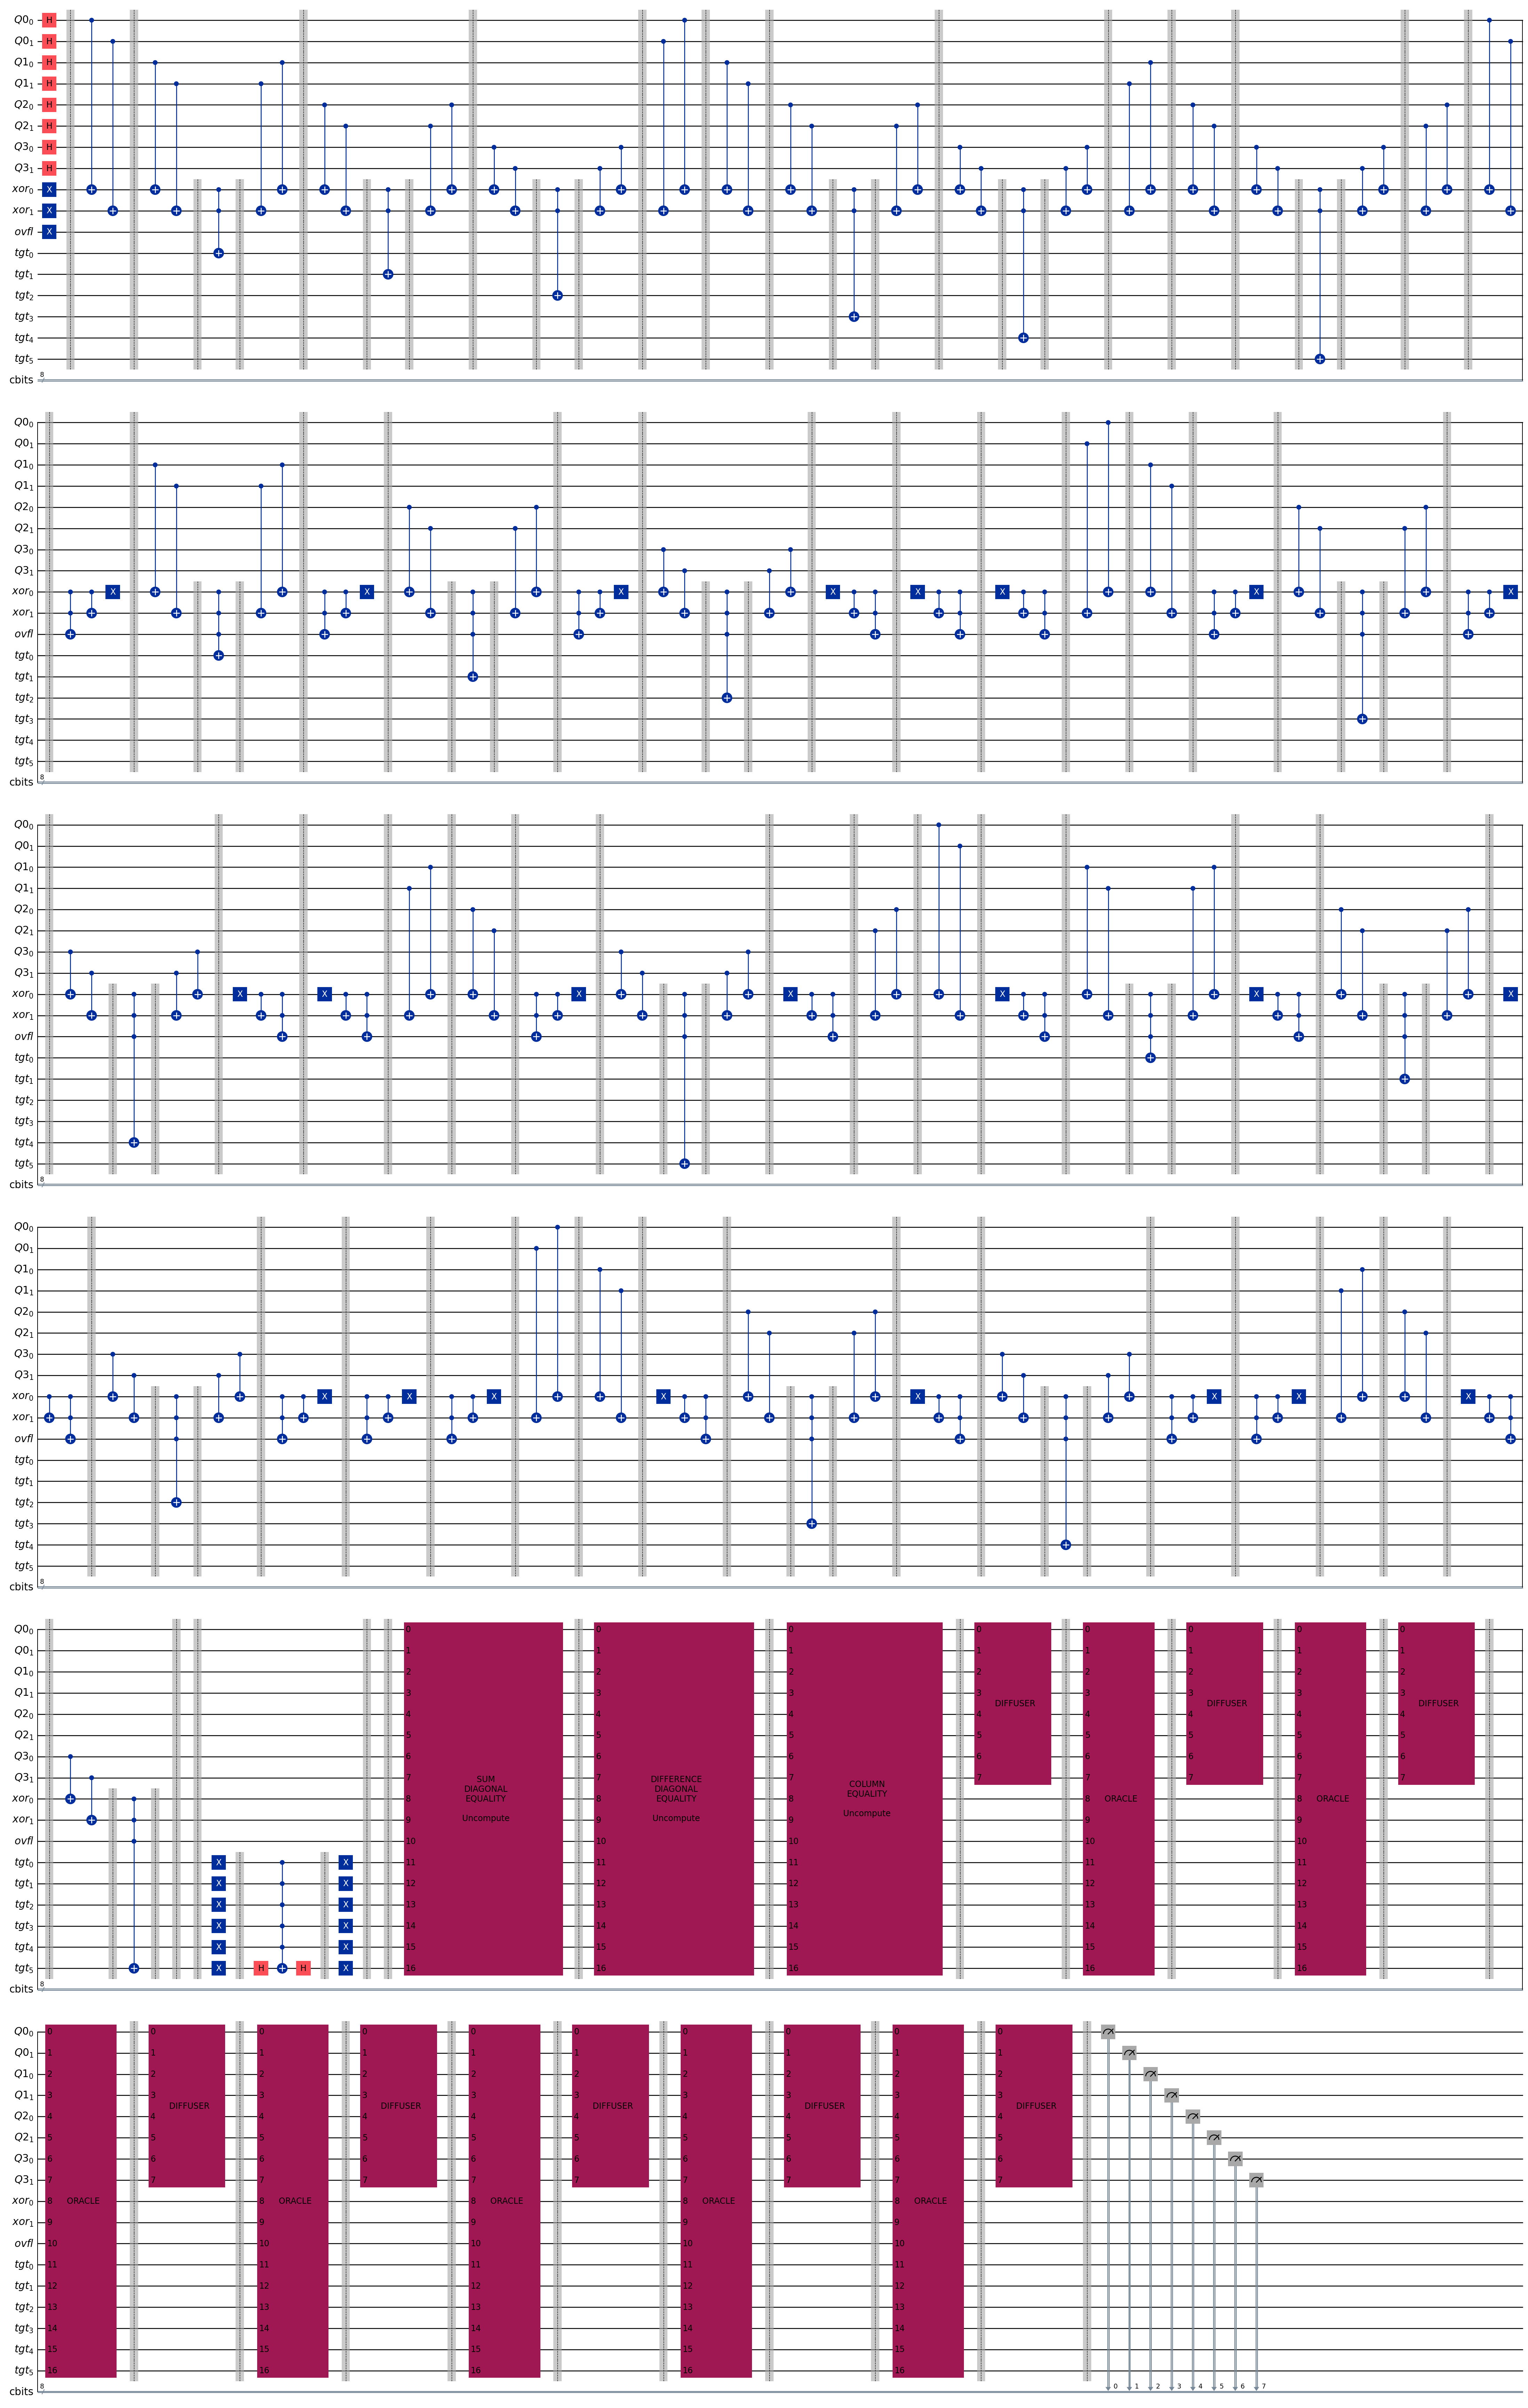

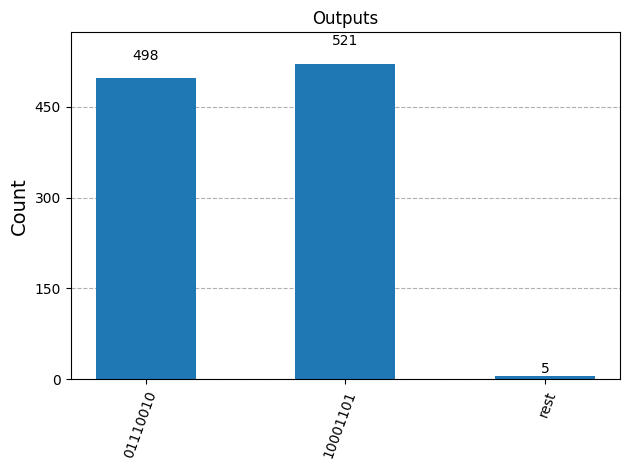

In [27]:
# QUEENS PROBLEM
def queens_problem():
    
    # circuit
    qc = QuantumCircuit(QuantumRegister(2,'Q0'), QuantumRegister(2,'Q1'), QuantumRegister(2,'Q2'), QuantumRegister(2,'Q3'), 
                        QuantumRegister(2,'xor'), 
                        QuantumRegister(1,'ovfl'),
                        QuantumRegister(6,'tgt'),
                        ClassicalRegister(8,'cbits'))

    # H on state qbits
    qc.h(range(n))

    # X on xor and ovfl qbits
    qc.x([8,9,10])

    qc.barrier()

    # oracle
    oracle_qc = oracle(QuantumCircuit(17, name = 'oracle'))
    oracle_gate = RemoveBarriers()(oracle_qc).to_gate(label='          ORACLE          ')

    # diffuser
    dif_qc = diffuser(QuantumCircuit(n))
    dif_gate = RemoveBarriers()(dif_qc).to_gate(label='          DIFFUSER          ')

    # grover iterations
    for i in range(grover_iterations):
        if i == 0:
            if abstraction_level == 4:
                qc.compose(oracle_gate, range(17), inplace=True)
            else:
                qc.compose(oracle_qc, range(17), inplace=True)
        else:
            qc.compose(oracle_gate, range(17), inplace=True)
        qc.barrier()
        qc.compose(dif_gate, range(n), inplace=True)

        qc.barrier()

    # measurement
    qc.measure(range(n), range(n))

    return qc


qc = queens_problem()


if abstraction_level == 1:
    qc = qc.decompose(gates_to_decompose=['col_eq', 'diff_diag_eq', 'sum_diag_eq'])
    qc = qc.decompose(gates_to_decompose=['ceq_pair', 'deq_pair']) 
elif abstraction_level == 2:
    qc = qc.decompose(gates_to_decompose=['col_eq', 'diff_diag_eq', 'sum_diag_eq'])


counts = execution(qc)


display(qc.draw('mpl', style={'fontsize':18, 'subfontsize':13, 'gatetextcolor':'black'}, fold=max(70, qc.depth()//5), scale=max(0.5, 1.0 - qc.depth()/3000)))

plot_histogram(counts, number_to_keep=M, title='Outputs')

In [28]:
# PRINT BOARDS

def print_boards(counts):

    solutions = sorted(counts, key=counts.get, reverse=True)[:M]
    solutions = sorted(solutions, key=lambda item: int(item, 2))
    
    for i, solution in enumerate(solutions):
        
        columns = [int(solution[-n:][j:j+2], 2) for j in range(0, n, 2)][::-1]
        
        print(f"\nSolution {i+1}: {columns}\n")
        
        for r in range(N):
            line = " ".join("♛" if columns[r] == c else "·" for c in range(N))
            print(f"| {line} |")
        
        print()


print_boards(counts)


Solution 1: [2, 0, 3, 1]

| · · ♛ · |
| ♛ · · · |
| · · · ♛ |
| · ♛ · · |


Solution 2: [1, 3, 0, 2]

| · ♛ · · |
| · · · ♛ |
| ♛ · · · |
| · · ♛ · |

